# Análisis y procesamiento de señales

## Trabajo práctico Nro 0

### Ferreyra Valentina

El objetivo de este primer trabajo práctico es implementar un generador de señales utilizando Python. 
Se desarrollará una función capaz de generar una señal senoidal a partir de distintos parámetros, como amplitud, valor medio, frecuencia, fase, cantidad de muestras y frecuencia de muestreo.

También se analizará el comportamiento de señales con distintas frecuencias respecto de una frecuencia de muestreo fija y se implementará una señal cuadrada.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

Para generar la señal se definieron distintos parámetros que permiten modificar sus características y determinar la función a generar

In [34]:
N = 1000
fs = 1000
vmax = 1.5
dc = 0
ph = 0
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    
    tt = np.arange(nn) / fs # tt: vector del tiempo.Todos los instantes en los que tomás una muestra de la señal.

    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    
    return (tt,xx)

def mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs):

    tt = np.arange(nn) / fs

    seno = np.sin(2 * np.pi * ff * tt + ph)

    zz = dc + vmax * np.where(seno >= 0, 1, -1)

    return tt, zz

A partir de esto se irán modificando los valores de frecuencia para observar cómo cambia la señal obtenida y analizar su comportamiento para una frecuencia de muestreo fija.

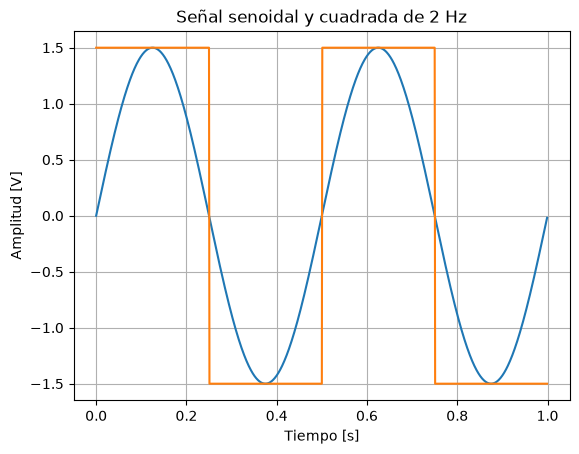

In [35]:
ff = 2

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, N, fs)
tt, zz = mi_funcion_cuadrada(vmax, dc, ff, ph, N, fs)

plt.figure()

plt.plot(tt, xx)
plt.plot(tt, zz)

plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal y cuadrada de 2 Hz")

plt.show()

Notemos entonces que como la frecuencia fue definida en 3 Hz, el gráfico muestra tres ciclos por segundo en ambas señales

Cambiamos la frecuencia a 100 Hz y nos queda:

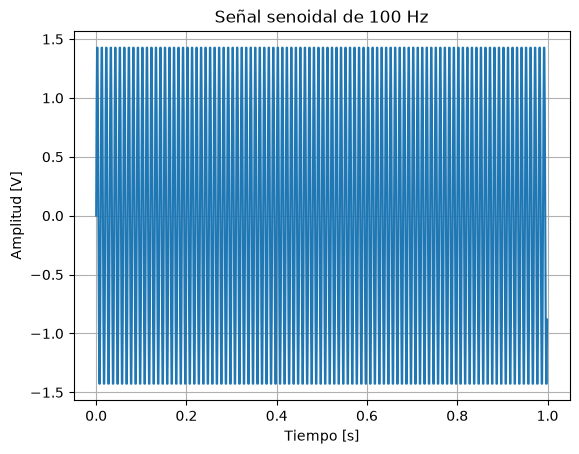

In [36]:
ff = 100

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, N, fs)

plt.figure()

plt.plot(tt, xx)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 100 Hz")
plt.show()

Hacemos lo mismo pero ahora con la función cuadrada

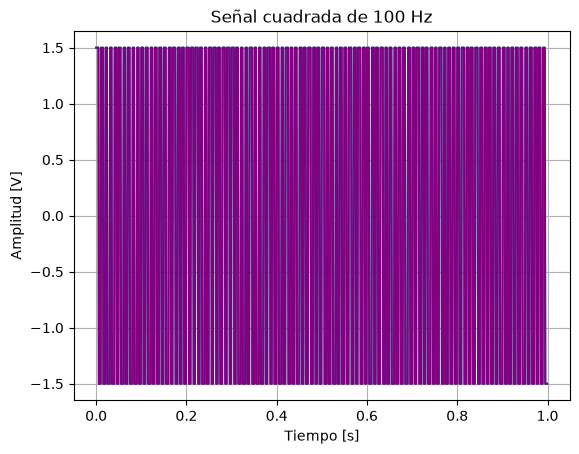

In [39]:
ff = 100

tt, zz = mi_funcion_cuadrada(vmax, dc, ff, ph, N, fs)

plt.figure()

plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuadrada de 100 Hz")
plt.plot(tt, zz, color="purple")

plt.show()

Al tener una frecuencia de 100 Hz, la señal presenta una cantidad mayor de ciclos por segundo, por eso el gráfico se ve más denso

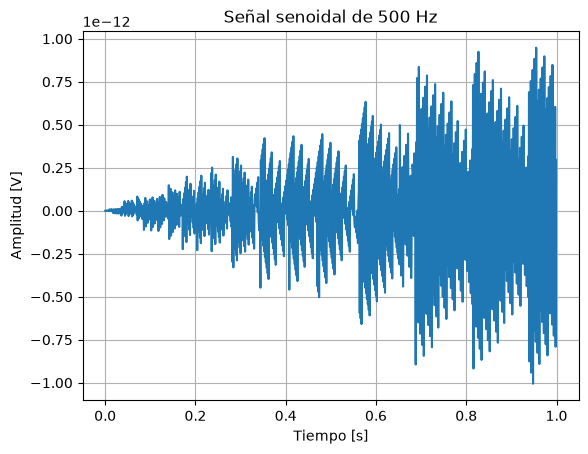

In [40]:
ff = 500

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, N, fs)

plt.figure()
plt.plot(tt, xx)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 500 Hz")
plt.show()

Para una frecuencia de muestreo igual a 1000 Hz la frecuencia de Nyquist es fs/2 = 500 Hz. Por lo tanto, una frecuencia de 500 Hz se encuentra justo en el límite de Nyquist, donde se obtienen dos muestras por periodo. Con fase inicial nula, las muestras coinciden con los cruces por cero de la senoide, por lo que la señal muestreada resulta prácticamente nula.
Los pequeños valores observados, del orden de 10^−12 se deben a errores numéricos de precisión de la computadora.

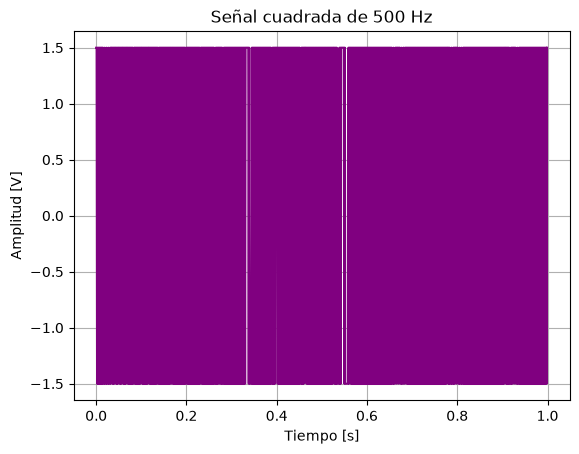

In [42]:
ff = 500

tt, zz = mi_funcion_cuadrada(vmax, dc, ff, ph, N, fs)

plt.figure()
plt.plot(tt, zz,color="purple")
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuadrada de 500 Hz")
plt.show()

En el caso de la señal cuadrada, al determinar sus niveles a partir del signo de la senoide, pequeños errores numéricos pueden provocar cambios entre los niveles positivo y negativo aunque teóricamente las muestras de la senoide sean nulas.

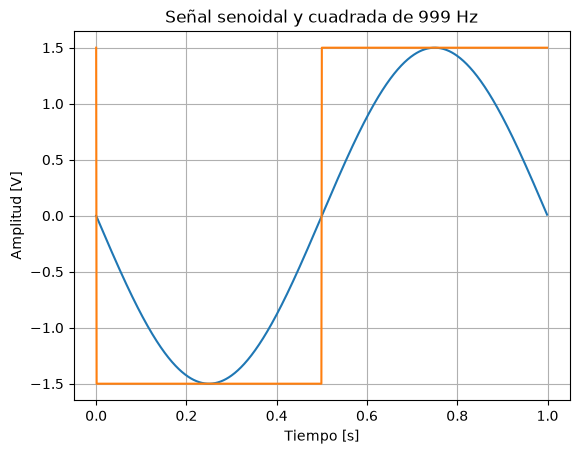

In [43]:
ff = 999 

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, N, fs)
tt, zz = mi_funcion_cuadrada(vmax, dc, ff, ph, N, fs)

plt.figure()
plt.plot(tt, xx)
plt.plot(tt, zz)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal y cuadrada de 999 Hz")
plt.show()

Como 999 Hz está por encima de la frecuencia de Nyquist, aparece aliasing. Al muestrear con fs = 1000Hz, la señal se observa como una de 1Hz pero invertida, ya que 999 = 1000 − 1.

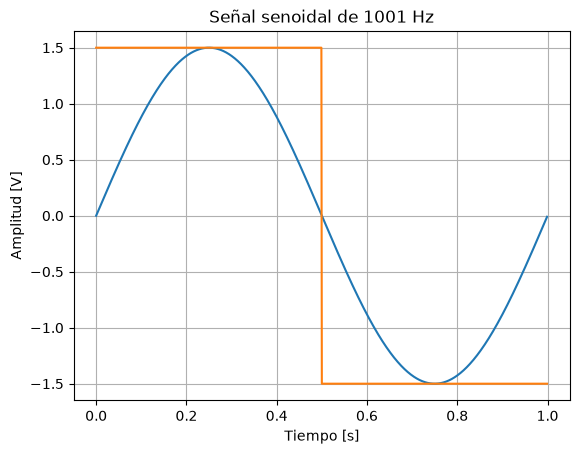

In [44]:
ff = 1001

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, N, fs)
tt, zz = mi_funcion_cuadrada(vmax, dc, ff, ph, N, fs)

plt.figure()
plt.plot(tt, xx)
plt.plot(tt, zz)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 1001 Hz")
plt.show()

Acá sucede algo parecido al caso anterior. Como la frecuencia también supera el límite de Nyquist, aparece aliasing. La señal resultante vuelve a verse como una señal de 1 Hz, aunque sin inversión de fase.

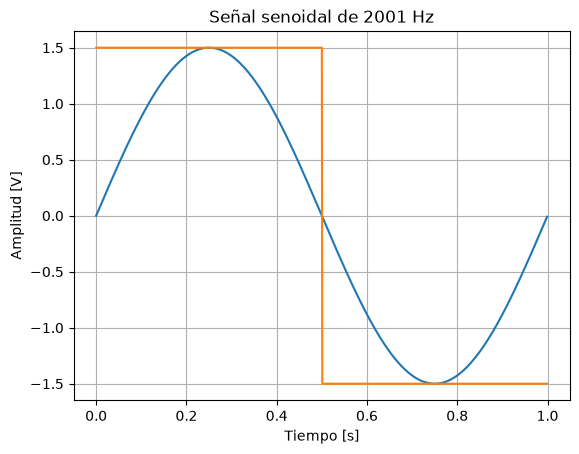

In [45]:
ff = 2001 

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, N, fs)
tt, zz = mi_funcion_cuadrada(vmax, dc, ff, ph, N, fs)

plt.figure()
plt.plot(tt, xx)
plt.plot(tt, zz)
plt.grid()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal de 2001 Hz")
plt.show()

In [49]:
import os
print(os.getcwd())

C:\Users\ferre\Documents\Analisis_Senales\pdstestbench


En este caso también se observa aliasing, ya que la frecuencia es muy superior a la de Nyquist. Como 2001 = 2fs +1, con fs = 1000Hz, las muestras resultan equivalentes a las de una señal de 1 Hz. Por eso la señal muestreada vuelve a comportarse como una señal de 1 Hz.

A partir de las distintas simulaciones se pudo observar cómo la frecuencia de muestreo condiciona la representación digital de una señal. Para frecuencias superiores al límite de Nyquist aparece aliasing, haciendo que señales de frecuencias muy diferentes puedan verse como una misma señal de menor frecuencia.